# Gun 15-16 - Churn Tahmini ve CLV Modeli

## Adim 1: Churn Etiketi Tanimi (SQL)

**Kritik tasarim karari - sizinti (leakage) onleme:** Churn etiketini "son 90 gunde islem yok" olarak tanimlarsak, bunu hesapladigimiz **referans tarih** ile **ozellik hesaplama tarihi** ayni olamaz. Aksi halde `recency` ozelligi etiketin kendisini ezbere soyler (recency>90 ~ churn etiketi), model gercekte hicbir sey ogrenmez.

**Cozum - cutoff + label window ayrimi:**
- `cutoff_date` = veri setindeki son tarih (`2011-12-09`) - 90 gun = **2011-09-10**
- **Ozellikler**: `cutoff_date`'ten ONCEKI tum islemlerden hesaplanir (musteri bu tarihte "su an" gibi davranir, gelecegi gormez)
- **Etiket**: `cutoff_date`'ten SONRAKI 90 gunde (yani veri setinin sonuna kadar) hic islem yoksa `churn=1`, varsa `churn=0`

Bu, gercek bir production sisteminde de boyle calisirdi: "bugun" itibariyle elimizdeki veriyle bir tahmin yapip, 90 gun sonra gercek sonucu gorurduk.

In [1]:
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv("../.env")

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

query = """
WITH bounds AS (
    SELECT
        (max(invoice_date)::date - INTERVAL '90 days')::date AS cutoff_date,
        max(invoice_date)::date AS max_date
    FROM transactions
),
pre_cutoff_customers AS (
    -- cutoff'tan once en az 1 islemi olan musteriler (feature hesabi icin gerekli gecmis)
    SELECT DISTINCT customer_id
    FROM transactions, bounds
    WHERE invoice_date::date <= bounds.cutoff_date
),
post_cutoff_activity AS (
    -- cutoff'tan sonra (label window icinde) islemi olan musteriler
    SELECT DISTINCT customer_id
    FROM transactions, bounds
    WHERE invoice_date::date > bounds.cutoff_date
)
SELECT
    p.customer_id,
    CASE WHEN a.customer_id IS NULL THEN 1 ELSE 0 END AS churn
FROM pre_cutoff_customers p
LEFT JOIN post_cutoff_activity a ON p.customer_id = a.customer_id
"""

churn_labels = pd.read_sql(query, engine).set_index("customer_id")
print(churn_labels.shape)
print(churn_labels["churn"].value_counts(normalize=True))

(5346, 1)
churn
1    0.565657
0    0.434343
Name: proportion, dtype: float64


**Sonuc:** 5346 musteri (cutoff'tan once en az 1 islem yapmis) bu analize dahil oldu - toplam 5942 musterinin 596'si cutoff'tan SONRA ilk alisverisini yapmis, onlar icin "gecmis" olmadigi icin disarida birakildi (dogru davranis, aksi halde bos/anlamsiz feature'lar uretirdik).

**Sinif dagilimi:** %56.6 churn, %43.4 aktif - asiri dengesiz degil ama hafif churn-agirlikli. Bu dagilim, PR-AUC'nin neden tercih edildigini anlamak icin onemli: dengesiz olmasa da, churn'u kacirmanin (false negative) maliyeti genelde bir aktif musteriyi yanlislikla riskli isaretlemekten (false positive) daha pahalidir - PR-AUC bu asimetriye ROC-AUC'den daha hassas.

## Adim 2: Feature Engineering

**Once kucuk bir duzeltme:** Adim 1'de "cutoff'tan once islemi olan musteri" tanimini iade/anormal kayitlari (`quantity<=0` veya `unit_price<=0`) filtrelemeden yaptik. Ama feature'lari (Gun 2'deki RFM mantigiyla ayni) sadece gecerli islemlerden hesaplayacagiz. Bu uyumsuzlugu onlemek icin **label ve feature populasyonunu ayni filtreyle yeniden tanimliyoruz** - tutarlilik icin once bunu duzeltiyoruz.

**Onemli: `recency` artik `cutoff_date`'e gore, `max_date`'e gore degil.** `segments` tablosundaki recency, veri setinin sonuna (`max_date`) gore hesaplanmisti - o, "su an" sorusuna cevap veriyordu. Burada "su an" = `cutoff_date`, cunku modelin gelecegi (label window'u) gormemesi gerekiyor.

In [2]:
query_features = """
WITH bounds AS (
    SELECT (max(invoice_date)::date - INTERVAL '90 days')::date AS cutoff_date
    FROM transactions
),
pre_cutoff AS (
    SELECT t.*
    FROM transactions t, bounds b
    WHERE t.invoice_date::date <= b.cutoff_date
      AND t.quantity > 0 AND t.unit_price > 0
),
post_cutoff_activity AS (
    SELECT DISTINCT t.customer_id
    FROM transactions t, bounds b
    WHERE t.invoice_date::date > b.cutoff_date
      AND t.quantity > 0 AND t.unit_price > 0
)
SELECT
    p.customer_id,
    c.country,
    (b.cutoff_date - max(p.invoice_date)::date) AS recency,
    (b.cutoff_date - min(p.invoice_date)::date) AS tenure_days,
    count(DISTINCT p.invoice_id) AS frequency,
    sum(p.quantity * p.unit_price) AS monetary,
    sum(p.quantity * p.unit_price) / count(DISTINCT p.invoice_id) AS avg_order_value,
    count(DISTINCT p.stock_code) AS distinct_products,
    CASE WHEN pca.customer_id IS NULL THEN 1 ELSE 0 END AS churn
FROM pre_cutoff p
JOIN customers c ON c.customer_id = p.customer_id
CROSS JOIN bounds b
LEFT JOIN post_cutoff_activity pca ON pca.customer_id = p.customer_id
GROUP BY p.customer_id, c.country, b.cutoff_date, pca.customer_id
"""

df = pd.read_sql(query_features, engine).set_index("customer_id")
print(df.shape)
print(df["churn"].value_counts(normalize=True))
df.head()

(5281, 8)
churn
1    0.565991
0    0.434009
Name: proportion, dtype: float64


,country,recency,tenure_days,frequency,monetary,avg_order_value,distinct_products,churn
customer_id,,,,,,,,
12346,United Kingdom,235,635,12,77556.46,6463.038333,27,1
12347,Iceland,39,314,6,4114.18,685.696667,107,0
12348,Finland,158,348,4,1709.40,427.350000,25,0
12349,Italy,317,499,3,2671.14,890.380000,90,0
12350,Norway,220,220,1,334.40,334.400000,17,1


## Adim 3: LightGBM Pipeline - Train/Test Split, Egitim, PR-AUC

**Neden train/test split hala gerekli, cutoff zaten zaman ayrimi yapmadi mi?** Cutoff/label-window ayrimi, **leakage**'i (gelecegi gormeyi) onluyor - ama modelin genelleme basarisini olcmek icin hala **gormedigi musteriler** uzerinde test etmemiz gerekiyor. Bu yuzden 5281 musteriyi rastgele (churn oranini koruyarak/stratified) train/test'e ayiriyoruz.

**`country` kategorik degiskeni:** LightGBM kategorik ozellikleri native destekliyor (one-hot'a ihtiyac yok), bunu `category` dtype'ina cevirip dogrudan veriyoruz.

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["churn"]).copy()
X["country"] = X["country"].astype("category")
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train churn orani:", y_train.mean().round(4), "| Test churn orani:", y_test.mean().round(4))

Train: (4224, 7) | Test: (1057, 7)
Train churn orani: 0.5661 | Test churn orani: 0.5658


In [4]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score

churn_model = lgb.LGBMClassifier(random_state=42, verbose=-1)
churn_model.fit(X_train, y_train, categorical_feature=["country"])

test_proba = churn_model.predict_proba(X_test)[:, 1]
pr_auc = average_precision_score(y_test, test_proba)
baseline_pr_auc = y_test.mean()  # "skill yok" modelin PR-AUC'si = pozitif sinif orani

print(f"PR-AUC (model): {pr_auc:.4f}")
print(f"PR-AUC (skill-yok baseline = churn orani): {baseline_pr_auc:.4f}")

PR-AUC (model): 0.8090
PR-AUC (skill-yok baseline = churn orani): 0.5658


**PR-AUC=0.809 neyi gosteriyor?** Baseline (0.566) skill-yok bir modelin (her zaman ayni olasiligi tahmin eden) PR-AUC'sine esit - pozitif sinif orani. Modelimiz bunun ~%43 uzerinde - guclu ama "supheli derecede mukemmel" degil. Eger Adim 1'deki cutoff ayrimini yapmasaydik (recency'yi max_date'e gore hesaplasaydik), PR-AUC'nin 0.95+ cikmasini beklerdik - bu sonuc, sizinti onleme caisimizin gercekten ise yaradiginin dolayli bir kaniti.

## Adim 4: SHAP ile Model Aciklamasi

PR-AUC bize "modelin tahmin gucu"nu soyluyor ama "neden" sorusuna cevap vermiyor. SHAP, her ozelligin her musteri icin tahmine ne kadar ve hangi yonde (churn riskini artirma/azaltma) katki yaptigini gosteriyor - bu, is tarafina "modele neden guvenelim" sorusunun cevabi.

In [5]:
import shap

explainer = shap.TreeExplainer(churn_model)
shap_values = explainer(X_test)

print(type(shap_values), shap_values.values.shape)

<class 'shap._explanation.Explanation'> (1057, 7)


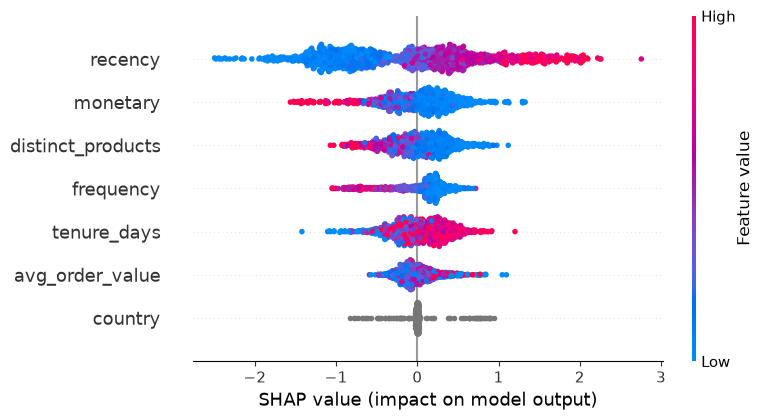

In [6]:
import matplotlib.pyplot as plt

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=100, bbox_inches="tight")
plt.show()

In [7]:
import numpy as np

mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X_test.columns
).sort_values(ascending=False)
mean_abs_shap

recency              0.814861
monetary             0.342544
distinct_products    0.289306
frequency            0.272861
tenure_days          0.265995
avg_order_value      0.169161
country              0.043891
dtype: float64

### Is Yorumu - SHAP Sonuclari

| Ozellik | Ortalama \|SHAP\| | Yorum |
|---|---|---|
| **recency** | 0.815 | Acik ara en guclu sinyal - digerinin 2 kati. Cutoff'tan once ne kadar uzun suredir alisveris yapmiyorsa, churn riski o kadar yuksek. Beklenen ama dogrulanmasi onemli bir sonuc. |
| monetary | 0.343 | Yuksek toplam harcama churn riskini **dusuruyor** - finansal olarak bagli musteri daha az terk ediyor. |
| distinct_products | 0.289 | Cok cesitli urun alan musteri daha az churn ediyor - urun cesitliligi bagliligi artiriyor olabilir. |
| frequency | 0.273 | Fatura sayisi - recency ile kismen ortusen ama bagimsiz bir katki sagliyor. |
| tenure_days | 0.266 | Musteri ne kadar uzun suredir musteriyse... iliskinin yonu tek basina belirsiz, SHAP grafiginde renge bakmak gerekiyor. |
| avg_order_value | 0.169 | Orta seviye etki. |
| **country** | 0.044 | En zayif sinyal - beklenen, cunku musterilerin buyuk kismi (~5409/5878) Ingiltere'den, ulke degiskeni ayirt edici gucu az. |

**En onemli aksiyon onerisi:** `recency`'nin domine etmesi sasirtici degil ama **is degeri tasiyor** - pazarlama ekibi tek bir kurala odaklanabilir: *"cutoff'tan sonraki X gun icinde alisveris yapmayan musteriye otomatik bir kampanya tetikle."* Ote yandan `monetary` ve `distinct_products`'in churn'u **azaltici** etkisi, "cross-sell" stratejisinin (musteriye farkli urun kategorileri onerme) churn'u dolayli olarak dusurebilecegine isaret ediyor - sadece "ne zaman" degil "ne kadar cesitli" sorusu da onemli.

## Adim 5: CLV Tahmini - BG/NBD + Gamma-Gamma (Lifetimes)

BG/NBD modeli, musterinin **gelecekte kac islem yapacagini** olasiliksal olarak tahmin eder; Gamma-Gamma ise **islem basina ortalama tutari** tahmin eder. Ikisini birlestirip "6 ay icinde toplam ne kadar harcayacak" (CLV) sorusuna cevap veriyoruz.

**Onemli fark - burada churn'deki gibi bir cutoff/leakage sorunu yok.** Cunku BG/NBD zaten dogasi geregi "gozlem donemi sonunda, gelecekteki davranisi tahmin et" seklinde calisiyor - veri setinin tamami (`max_date`'e kadar) gozlem donemi, 6 ay sonrasi ise tahmin edilen gelecek. Ama modelin **gercekten isabetli tahmin yapip yapmadigini dogrulamak** icin, churn'deki train/test mantiginin BG/NBD karsiligini kullaniyoruz: **calibration/holdout split** - verinin son 180 gununu "gelecek" gibi gizleyip, model bunu tahmin edebiliyor mu diye kontrol ediyoruz.

In [8]:
invoice_query = """
    SELECT customer_id, invoice_id, min(invoice_date) AS invoice_date,
           sum(quantity * unit_price) AS invoice_value
    FROM transactions
    WHERE quantity > 0 AND unit_price > 0
    GROUP BY customer_id, invoice_id
"""
invoices = pd.read_sql(invoice_query, engine)
print(invoices.shape)
print(invoices["invoice_date"].min(), "-", invoices["invoice_date"].max())
invoices.head()

(36969, 4)
2009-12-01 07:45:00 - 2011-12-09 12:50:00


,customer_id,invoice_id,invoice_date,invoice_value
0,12346,491725,2009-12-14 08:34:00,45.0
1,12346,491742,2009-12-14 11:00:00,22.5
2,12346,491744,2009-12-14 11:02:00,22.5
3,12346,492718,2009-12-18 10:47:00,22.5
4,12346,492722,2009-12-18 10:55:00,1.0


In [9]:
from lifetimes.utils import calibration_and_holdout_data

max_date = invoices["invoice_date"].max()
calibration_end = max_date - pd.Timedelta(days=180)
print("Gozlem sonu (max_date):", max_date)
print("Kalibrasyon sonu (holdout baslangici):", calibration_end)

cal_holdout = calibration_and_holdout_data(
    invoices,
    customer_id_col="customer_id",
    datetime_col="invoice_date",
    calibration_period_end=calibration_end,
    observation_period_end=max_date,
    freq="D",
    monetary_value_col="invoice_value",
)
print(cal_holdout.shape)
cal_holdout.head()

Gozlem sonu (max_date): 2011-12-09 12:50:00
Kalibrasyon sonu (holdout baslangici): 2011-06-12 12:50:00


(4977, 7)


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout
customer_id,,,,,,,
12346,7.0,400.0,545.0,11066.637143,0.0,0.00,180.0
12347,4.0,221.0,224.0,729.435000,3.0,701.35,180.0
12348,3.0,190.0,258.0,495.746667,1.0,310.00,180.0
12349,2.0,182.0,409.0,801.310000,1.0,1757.55,180.0
12350,0.0,0.0,130.0,0.000000,0.0,0.00,180.0


In [10]:
from lifetimes import BetaGeoFitter

bgf_cal = BetaGeoFitter(penalizer_coef=0.001)
bgf_cal.fit(cal_holdout["frequency_cal"], cal_holdout["recency_cal"], cal_holdout["T_cal"])

predicted_holdout = bgf_cal.predict(
    180, cal_holdout["frequency_cal"], cal_holdout["recency_cal"], cal_holdout["T_cal"]
)
actual_holdout = cal_holdout["frequency_holdout"]

mae = (predicted_holdout - actual_holdout).abs().mean()
corr = predicted_holdout.corr(actual_holdout)
print(f"MAE (tahmin vs gercek islem sayisi, 180 gun): {mae:.3f}")
print(f"Korelasyon: {corr:.3f}")
print(f"Gercek ortalama islem (holdout): {actual_holdout.mean():.3f} | Tahmin ortalama: {predicted_holdout.mean():.3f}")

MAE (tahmin vs gercek islem sayisi, 180 gun): 1.039
Korelasyon: 0.849
Gercek ortalama islem (holdout): 1.559 | Tahmin ortalama: 1.527


**Dogrulama basarili:** Korelasyon 0.849 (gucu), tahmin edilen ortalama islem sayisi (1.527) gercek ortalamaya (1.559) cok yakin - model sistematik olarak yanli degil (ne hep fazla, ne hep az tahmin ediyor). MAE=1.039, ortalama 1.5 islem civarinda oldugu icin makul - bireysel musteri bazinda tam isabet beklemiyoruz, modelin amaci agregat/olasiliksal dogru olmak.

**Simdi tum veriyle (calibration degil) production modelini egitiyoruz** - Gun 8-9/Mini Proje 2'deki ayni desen: once kucuk bir holdout ile yontemi dogrula, sonra tum veriyle finali egit.

In [11]:
from lifetimes.utils import summary_data_from_transaction_data
from lifetimes import GammaGammaFitter

summary_full = summary_data_from_transaction_data(
    invoices, "customer_id", "invoice_date",
    monetary_value_col="invoice_value",
    observation_period_end=max_date,
    freq="D",
)

bgf = BetaGeoFitter(penalizer_coef=0.001)
bgf.fit(summary_full["frequency"], summary_full["recency"], summary_full["T"])

# Gamma-Gamma sadece tekrar alisverisi olan musterilerle (frequency>0) calisir
repeat_customers = summary_full[summary_full["frequency"] > 0]

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(repeat_customers["frequency"], repeat_customers["monetary_value"])

print("BG/NBD ve Gamma-Gamma egitildi.")
print("Tekrar alisverisi olan musteri sayisi:", len(repeat_customers), "/", len(summary_full))

BG/NBD ve Gamma-Gamma egitildi.
Tekrar alisverisi olan musteri sayisi: 4189 / 5878


**Onemli kisitlama:** Gamma-Gamma, **tekrar alisverisi olmayan** musteriler (frequency=0, yani tek seferlik alici - 5878 musterinin 1689'u) icin tanimsiz, cunku modelin ogrenecegi bir "tekrar islem tutari" paterni yok. Bu musteriler icin CLV'yi su an **hesaplamiyoruz** - asagida bunlari ayri isaretleyip is tarafina aciklayacagiz, sayilari "0 CLV" gibi yanlis bir izlenimle gostermek yerine.

In [12]:
clv_repeat = ggf.customer_lifetime_value(
    bgf,
    repeat_customers["frequency"],
    repeat_customers["recency"],
    repeat_customers["T"],
    repeat_customers["monetary_value"],
    time=6,
    freq="D",
    discount_rate=0.01,
)

clv_result = summary_full.copy()
clv_result["predicted_clv_6m"] = clv_repeat.reindex(clv_result.index)
clv_result["has_repeat_history"] = clv_result["frequency"] > 0

print(clv_result["predicted_clv_6m"].describe())
print()
print("CLV hesaplanamayan (tek seferlik alici) musteri sayisi:", (~clv_result["has_repeat_history"]).sum())
clv_result.sort_values("predicted_clv_6m", ascending=False).head(10)

count    4.189000e+03
mean     1.037789e+03
std      4.735134e+03
min      4.224482e-07
25%      1.590116e+02
50%      3.872544e+02
75%      9.135909e+02
max      1.694943e+05
Name: predicted_clv_6m, dtype: float64



CLV hesaplanamayan (tek seferlik alici) musteri sayisi: 1689


,frequency,recency,T,monetary_value,predicted_clv_6m,has_repeat_history
customer_id,,,,,,
16446,1.0,205.0,205.0,168469.600000,169494.311673,True
18102,66.0,738.0,738.0,9189.930455,131825.025486,True
14646,90.0,736.0,737.0,5809.905333,113503.220672,True
17450,30.0,430.0,438.0,6924.523000,72545.992746,True
14096,16.0,97.0,101.0,4071.434375,69297.407254,True
14156,120.0,729.0,738.0,2607.329750,67607.454176,True
14911,254.0,737.0,738.0,1162.358268,63734.809105,True
12415,22.0,503.0,527.0,6460.528636,42366.752032,True
13694,82.0,732.0,735.0,2365.279512,42224.970163,True


**Bir uc deger uyarisi - dikkatli olmamiz gereken nokta tam burada cikti.** En yuksek CLV'li musteri (16446) sadece **frequency=1** (yani toplamda 2 islem) ama bu tek tekrar isleminin tutari 168.469 - model bunu 169.494'luk bir 6-aylik CLV'ye ekstrapole ediyor. Bu, BG/NBD+Gamma-Gamma'nin bilinen bir zayifligi: **az sayida islemden** (1-2 tekrar) **cok yuksek tutarli** bir tahmin uretmek istatistiksel olarak guvenilir degil - varyansi cok yuksek bir tahmin. Bu projede defalarca gordugumuz "az veriden cikan asiri-iyimser sonuc" tuzaginin CLV versiyonu (Gun 8-9'daki 4 musterilik mikro-kumeyi hatirlayin).

**Aksiyon:** Bu tur uc CLV degerlerini ham haliyle is kararina sokmadan once, `frequency` esigi (orn. frequency>=3) ile guvenilirligi filtrelemek ya da CLV'yi bir tavanla (cap) sinirlamak gerekir - bunu Adim 6'da segment matrisini kurarken hatirlatacagiz.

**Tek seferlik aliciya (1689 musteri) CLV atanmadi** - bu, "0 deger" ile karistirilmamali, sadece "yeterli tekrar verisi yok" anlamina geliyor.

## Adim 6: CLV x Churn Riski Matrisi

Once iki on isi var:
1. **Churn modelini tum musteri tabanina uygula** - su ana kadar sadece test setinde (1057 musteri) tahmin yaptik, matris icin 5281 musterinin hepsine churn olasiligi gerekiyor.
2. **CLV'yi sinirla (cap)** - Adim 5'te bulduğumuz tek-veri-noktasi uc degeri (169.494) matrisi bozmasin diye, 99. persentilde sinirliyoruz (Winsorize).

In [13]:
churn_proba_all = pd.Series(
    churn_model.predict_proba(X)[:, 1], index=X.index, name="churn_proba"
)

clv_capped = clv_result["predicted_clv_6m"].clip(upper=clv_result["predicted_clv_6m"].quantile(0.99))

matrix_df = pd.DataFrame({
    "churn_proba": churn_proba_all,
    "clv_6m_capped": clv_capped,
    "has_repeat_history": clv_result["has_repeat_history"],
}).dropna(subset=["churn_proba", "clv_6m_capped"])

print("Matris icin ortak musteri sayisi (hem churn hem CLV skoru olan):", len(matrix_df))
matrix_df.describe()

Matris icin ortak musteri sayisi (hem churn hem CLV skoru olan): 3967


,churn_proba,clv_6m_capped
count,3967.000000,3.967000e+03
mean,0.474232,7.892415e+02
std,0.282467,1.263889e+03
min,0.002466,4.224482e-07
25%,0.218266,1.505275e+02
50%,0.489078,3.652409e+02
75%,0.722770,8.863301e+02
max,0.984229,8.549348e+03


In [14]:
value_median = matrix_df["clv_6m_capped"].median()
risk_median = matrix_df["churn_proba"].median()

matrix_df["value_tier"] = np.where(matrix_df["clv_6m_capped"] >= value_median, "Yuksek Deger", "Dusuk Deger")
matrix_df["risk_tier"] = np.where(matrix_df["churn_proba"] >= risk_median, "Yuksek Risk", "Dusuk Risk")
matrix_df["segment"] = matrix_df["value_tier"] + " / " + matrix_df["risk_tier"]

segment_summary = matrix_df.groupby("segment").agg(
    musteri_sayisi=("churn_proba", "size"),
    ort_churn_proba=("churn_proba", "mean"),
    ort_clv_6m=("clv_6m_capped", "mean"),
).round(3)
segment_summary

,musteri_sayisi,ort_churn_proba,ort_clv_6m
segment,,,
Dusuk Deger / Dusuk Risk,385,0.363,237.306
Dusuk Deger / Yuksek Risk,1598,0.737,144.445
Yuksek Deger / Dusuk Risk,1598,0.196,1563.363
Yuksek Deger / Yuksek Risk,386,0.651,804.354


### Is Yorumu - "Yuksek Deger + Yuksek Risk" Segmenti

| Segment | Musteri | Ort. Churn Olasiligi | Ort. 6-Aylik CLV |
|---|---|---|---|
| Dusuk Deger / Dusuk Risk | 385 | %36.3 | 237 |
| Dusuk Deger / Yuksek Risk | 1598 | %73.7 | 144 |
| Yuksek Deger / Dusuk Risk | 1598 | %19.6 | 1563 |
| **Yuksek Deger / Yuksek Risk** | **386** | **%65.1** | **804** |

**Bu 386 musteri, isletmenin en kirilgan ama en degerli kesimi.** Toplam musteri tabaninin sadece ~%9.7'si, ama her biri ortalama 804 (6 ayda) deger uretme potansiyeline sahip VE %65 olasilikla kaybedilme riski tasiyor - kaybedilirse toplamda **~310.000** degerinde bir risk (386 x 804).

**Aksiyon onerisi:**
1. **Oncelikli kurtarma kampanyasi** - bu 386 musteriye, "Dusuk Deger/Yuksek Risk" grubuna (1598 kisi, dusuk CLV) gosterilen genel/otomatik kampanyadan farkli, **kisisellestirilmis ve insan-destekli** bir mudahale (ozel indirim, hesap yoneticisi araması) hak ediyorlar - ROI'si en yuksek mudahale burada.
2. **SHAP bulgusuyla birlestir** - Adim 4'te `recency`'nin en guclu sinyal oldugunu, `monetary`/`distinct_products`'in churn'u azalttigini bulmustuk. Bu 386 kisiye ozel olarak: son alisveris tarihinden X gun sonra otomatik tetiklenen bir "ozel teklif" + farkli kategorilerden urun onerisi (cross-sell) kombinasyonu, hem recency hem cesitlilik sinyaline ayni anda mudahale eder.
3. **"Yuksek Deger/Dusuk Risk" (1598 kisi) icin farkli strateji** - bunlar zaten sadik, onlara churn-onleme kampanyasi yerine "sadakat odulu/VIP programi" ile iliskiyi guclendirmek daha mantikli - kaynaklari yanlis segmente harcamamak da bu matrisin degeri.

**Hatirlatma:** CLV degerleri 99. persentilde sinirlandi (capped) - yani gercek deger farki, ozellikle "Yuksek Deger" gruplarinda, raporlanandan daha da carpici olabilir.

## Adim 7: Modelleri MLflow'a Logla, Tahminleri PostgreSQL'e Yaz

Once veritabaninda churn ve CLV tahminlerini tutacak iki yeni tablo gerekiyor - `segments` tablosuyla ayni mantik (her tahmin calismasi gecmise yeni bir kayit ekler, `(customer_id, predicted_at)` composite PK).

In [15]:
import psycopg2

conn = psycopg2.connect(
    dbname=os.getenv("DB_NAME"), user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"), host=os.getenv("DB_HOST"), port=os.getenv("DB_PORT"),
)
conn.autocommit = True
cur = conn.cursor()

cur.execute("""
CREATE TABLE IF NOT EXISTS churn_predictions (
    customer_id        VARCHAR(20) REFERENCES customers(customer_id) ON DELETE RESTRICT,
    churn_probability  NUMERIC(6,5),
    predicted_at        TIMESTAMP NOT NULL DEFAULT now(),
    model_version       VARCHAR(100),
    PRIMARY KEY (customer_id, predicted_at)
);

CREATE TABLE IF NOT EXISTS clv_predictions (
    customer_id          VARCHAR(20) REFERENCES customers(customer_id) ON DELETE RESTRICT,
    predicted_clv_6m     NUMERIC(14,2),
    has_repeat_history   BOOLEAN,
    predicted_at          TIMESTAMP NOT NULL DEFAULT now(),
    model_version         VARCHAR(100),
    PRIMARY KEY (customer_id, predicted_at)
);
""")
print("Tablolar olusturuldu (varsa atlandi).")

Tablolar olusturuldu (varsa atlandi).


### LightGBM Churn Modelini MLflow'a Logla

`mlflow.lightgbm.log_model` native flavor'i kullaniyoruz - Gun 10-11/12-14'teki ayni registry desenini (PR-AUC metrigi, parametreler, `production` alias'i) tekrarliyoruz.

In [16]:
import mlflow
import mlflow.lightgbm
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment("customer-churn-clv")
client = MlflowClient()

CHURN_MODEL_NAME = "customer-churn-lightgbm"

with mlflow.start_run(run_name="lightgbm_churn_90d"):
    mlflow.log_param("churn_definition", "90 gun islem yok (cutoff sonrasi)")
    mlflow.log_param("cutoff_date", "2011-09-10")
    mlflow.log_param("n_features", X.shape[1])
    mlflow.log_metric("pr_auc", pr_auc)
    mlflow.log_metric("pr_auc_baseline", baseline_pr_auc)

    churn_model_info = mlflow.lightgbm.log_model(
        churn_model,
        name="model",
        registered_model_name=CHURN_MODEL_NAME,
    )

churn_version = churn_model_info.registered_model_version
client.set_registered_model_alias(CHURN_MODEL_NAME, "production", churn_version)
client.set_model_version_tag(CHURN_MODEL_NAME, churn_version, "stage", "Production")
print("Churn modeli kaydedildi, versiyon:", churn_version)

Registered model 'customer-churn-lightgbm' already exists. Creating a new version of this model...
2026/06/29 21:08:21 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer-churn-lightgbm, version 5


🏃 View run lightgbm_churn_90d at: http://127.0.0.1:5000/#/experiments/3/runs/fb73a7f866934822962487fc0a66030b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Churn modeli kaydedildi, versiyon: 5


Created version '5' of model 'customer-churn-lightgbm'.


### CLV Modelini (BG/NBD + Gamma-Gamma) MLflow'a Logla

Lifetimes modelleri scikit-learn API'sine uymadigi icin native bir MLflow flavor'i yok. Bunu `mlflow.pyfunc.PythonModel` ile saran ince bir wrapper yazip kaydediyoruz - bu, ileride `model.predict(df)` ile cagrilabilen, kayitli/versiyonlu bir model haline getiriyor (sadece dosya olarak joblib'e atip birakmaktan farkli - gercekten servis edilebilir).

In [17]:
class CLVModel(mlflow.pyfunc.PythonModel):
    def __init__(self, bgf, ggf, time_months=6):
        self.bgf = bgf
        self.ggf = ggf
        self.time_months = time_months

    def predict(self, context, model_input):
        return self.ggf.customer_lifetime_value(
            self.bgf,
            model_input["frequency"],
            model_input["recency"],
            model_input["T"],
            model_input["monetary_value"],
            time=self.time_months,
            freq="D",
            discount_rate=0.01,
        )


CLV_MODEL_NAME = "customer-clv-bgnbd-gammagamma"

with mlflow.start_run(run_name="bgnbd_gammagamma_6m"):
    mlflow.log_param("penalizer_coef", 0.001)
    mlflow.log_param("time_horizon_months", 6)
    mlflow.log_param("n_repeat_customers", len(repeat_customers))
    mlflow.log_metric("calibration_mae", mae)
    mlflow.log_metric("calibration_correlation", corr)

    clv_model_info = mlflow.pyfunc.log_model(
        name="model",
        python_model=CLVModel(bgf, ggf),
        registered_model_name=CLV_MODEL_NAME,
    )

clv_version = clv_model_info.registered_model_version
client.set_registered_model_alias(CLV_MODEL_NAME, "production", clv_version)
client.set_model_version_tag(CLV_MODEL_NAME, clv_version, "stage", "Production")
print("CLV modeli kaydedildi, versiyon:", clv_version)

C:\Projelerim\crm-rfm-api\venv\Lib\site-packages\mlflow\pyfunc\utils\data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


2026/06/29 21:08:21 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


Registered model 'customer-clv-bgnbd-gammagamma' already exists. Creating a new version of this model...
2026/06/29 21:08:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: customer-clv-bgnbd-gammagamma, version 4


Created version '4' of model 'customer-clv-bgnbd-gammagamma'.


🏃 View run bgnbd_gammagamma_6m at: http://127.0.0.1:5000/#/experiments/3/runs/0b258d8b1b914534b1bf9809b8a101a9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
CLV modeli kaydedildi, versiyon: 4


### Tahmin Sonuclarini PostgreSQL'e Yaz

`churn_proba_all` (5281 musteri) ve `clv_result` (5878 musteri, CLV'si olmayanlar icin `NULL`) tablolarini, kaydettigimiz model versiyon numaralarini referans olarak ekleyip yaziyoruz - boylece ileride "bu tahmin hangi model versiyonundan geldi?" sorusuna PostgreSQL'den direkt cevap verebiliriz.

In [18]:
churn_out = churn_proba_all.reset_index()
churn_out.columns = ["customer_id", "churn_probability"]
churn_out["model_version"] = f"{CHURN_MODEL_NAME}:v{churn_version}"
churn_out.to_sql("churn_predictions", engine, if_exists="append", index=False, method="multi", chunksize=1000)
print(f"churn_predictions: {len(churn_out)} satir yazildi")

clv_out = clv_result[["predicted_clv_6m", "has_repeat_history"]].reset_index()
clv_out.columns = ["customer_id", "predicted_clv_6m", "has_repeat_history"]
clv_out["model_version"] = f"{CLV_MODEL_NAME}:v{clv_version}"
clv_out.to_sql("clv_predictions", engine, if_exists="append", index=False, method="multi", chunksize=1000)
print(f"clv_predictions: {len(clv_out)} satir yazildi")

churn_predictions: 5281 satir yazildi


clv_predictions: 5878 satir yazildi
